# Part 1: Random Froest Regressor with Smiles fingerprints input and ln(kd [or ki]) as target values

In [34]:
import pandas as pd
from scripts.preprocessing import PDBpreprocessing

raw_data = pd.read_csv("data/LP_PDBBind.csv")

preprocessed_data = PDBpreprocessing(raw_data, category= None, variable='both', keep_protein_chain=False, log_transform=True)
preprocessed_data.head()

✅ Cleaned dataset shape: (19121, 2)
   Dropped rows with None/NaN in ['smiles', 'target']


,smiles,target
0,CSc1ccccc1[C@H]1CCCN1C(=O)CNC(=O)NCc1ccc2c(c1)...,1.796016
1,O=C([O-])CCC[N@H+]1CCC[C@H]1COc1ccc(Oc2ccc(Cl)...,3.223619
2,CCC(CC)O[C@@H]1C[C@H](C(=O)[O-])C[C@H]([NH3+])...,-1.473654
3,CC[C@H](C)[C@H](NC(=O)CNC(=O)[C@H](C)NC(=O)[C@...,11.121486
4,[NH3+][C@@H](C[C@]1(C(=O)[O-])C[C@H]2OCC[C@@H]...,5.134765


# Data distribution


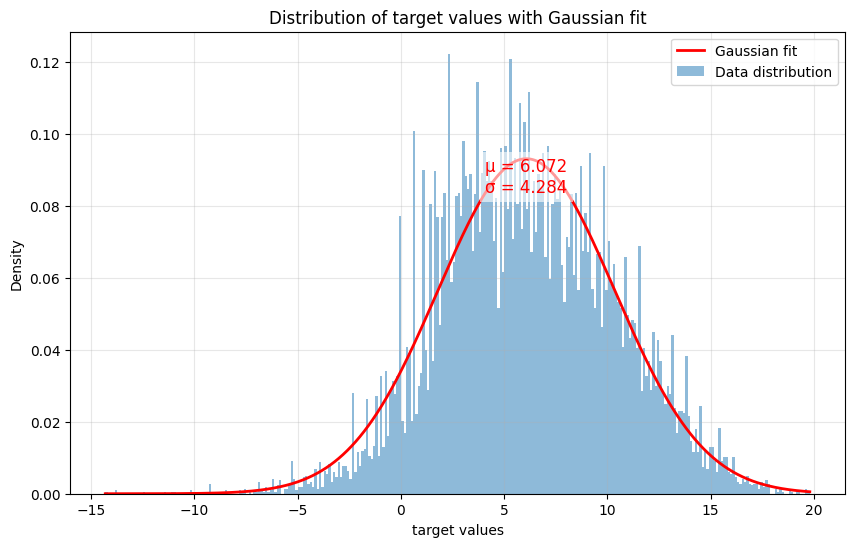

In [35]:
from scripts.regression_plots import gaussian_fit

# Extract data
data = preprocessed_data['target'].dropna().values
gaussian_fit(data)

# Hyperparameter optimization heatmaps & detailed results for the best model

In [36]:
# Fingerprint extraction and Random Forest Regression with hyperparameter optimization and standardized data
from rdkit import Chem
from rdkit.Chem import AllChem
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D
from scripts.regression_plots import prediction_plot

r_fingerprint=2
Bits_fingerprint=2048

# Extract Morgan fingerprints from SMILES
def smiles_to_fingerprint(smiles, radius=r_fingerprint, nBits=Bits_fingerprint):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.zeros(nBits)
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits)
    return np.array(fp)

X = np.array([smiles_to_fingerprint(s) for s in preprocessed_data['smiles']])
y = preprocessed_data['target'].values

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Hyperparameter grid for Random Forest
param_grid = {
    'n_estimators': np.linspace(10, 100, 5).astype(int),
    'max_depth': np.linspace(10, 100, 5).astype(int),
    'min_samples_split': [2]
}

rf = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1, return_train_score=True)
grid_search.fit(X_train, y_train)

# Best model and predictions
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)

# Metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Test MSE (standardized): {mse:.2f}")
print(f"Test R2 (standardized): {r2:.2f}")

# Prepare matrix for heatmap plots
results = grid_search.cv_results_
df_results = pd.DataFrame(results)
df_results['max_depth'] = df_results['param_max_depth'].fillna(-1).astype(int)
df_results['n_estimators'] = df_results['param_n_estimators'].astype(int)

# Choose a fixed value for min_samples_split, e.g. 2
fixed_split = 2
filtered = df_results[df_results['param_min_samples_split'] == fixed_split]

# Calculate MSE and R2 for each parameter combination
mse_matrix = filtered.pivot(index='max_depth', columns='n_estimators', values='mean_test_score')
r2_matrix = filtered.pivot(index='max_depth', columns='n_estimators', values='mean_train_score')

# Plot MSE heatmap (note: mean_test_score is negative MSE, so invert sign)
plt.figure(figsize=(8,6))
plt.title('Random Forest Hyperparameter Grid - MSE (CV, standardized)')
plt.xlabel('n_estimators')
plt.ylabel('max_depth')
im = plt.imshow(-mse_matrix.values, cmap='viridis', aspect='auto', origin='lower')
plt.xticks(np.arange(len(mse_matrix.columns)), mse_matrix.columns)
plt.yticks(np.arange(len(mse_matrix.index)), mse_matrix.index)
plt.colorbar(im, label='MSE')
plt.show()

# Plot R2 heatmap (using train score for illustration, can be replaced with test R2 if calculated)
plt.figure(figsize=(8,6))
plt.title('Random Forest Hyperparameter Grid - R2 (Train, standardized)')
plt.xlabel('n_estimators')
plt.ylabel('max_depth')
im = plt.imshow(r2_matrix.values, cmap='plasma', aspect='auto', origin='lower')
plt.xticks(np.arange(len(r2_matrix.columns)), r2_matrix.columns)
plt.yticks(np.arange(len(r2_matrix.index)), r2_matrix.index)
plt.colorbar(im, label='R2')
plt.show()


#best model evaluation plots
print("Best hyperparameters:", grid_search.best_params_)
gaussian_fit(y_pred)
prediction_plot(y_test, y_pred)

KeyboardInterrupt: 

# Part 2: Random Froest Regressor with Smiles fingerprints + Protein chains inputs and ln(kd [or ki]) as target values

✅ Cleaned dataset shape: (994, 3)
   Dropped rows with None/NaN in ['smiles', 'target', 'seq']


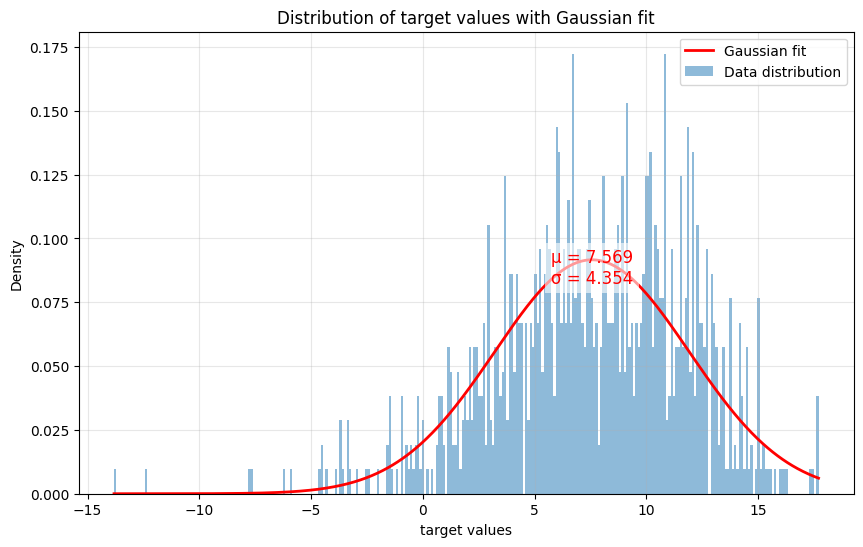

,smiles,target,seq
0,O=C([O-])CCC[N@H+]1CCC[C@H]1COc1ccc(Oc2ccc(Cl)...,3.223619,VDTCSLASPASVCRTKHLHLRCSVDFTRRTLTGTAALTVQSQEDNL...
1,Nc1nc(N2CC[NH+](CCOc3ccc(Br)cc3)CC2)n[nH]1,7.437350,YQLTCYFTNWAQYRPGLGRFMPDDINPCLCTHLIYAFAGMQNNEIT...
2,NC(=[NH2+])c1ccc(CNC(=O)[C@@H]2CCCN2C(=O)CCC2C...,6.332109,IVGGYTCGANTVPYQVSLNSGYHFCGGSLINSQWVVSAAHCYKSGI...
3,CC(=O)N[C@H]1[C@H](O[C@@H]2[C@@H](CO)O[C@@H](O...,9.555728,KVFGRCELAAAMKRHGLDNYRGYSLGNWVCAAKFESNFNTQATNRN...
4,C[C@H]1CCC[C@H](O)CCC/C=C/c2cc(O)cc(O)c2C(=O)O1,6.078825,TRTRGYVTTKDGIKWYYEQEGSGPDVVLIPDGLGECQMFDKPMSLI...


In [ ]:
preprocessed_data = PDBpreprocessing(raw_data, category= None, variable='both', keep_protein_chain=True, log_transform=True)
data = preprocessed_data['target'].dropna().values
gaussian_fit(data)  
preprocessed_data.head()

[17:42:08] Explicit valence for atom # 6 Br, 3, is greater than permitted


Test MSE (standardized): 7.10
Test R2 (standardized): 0.56


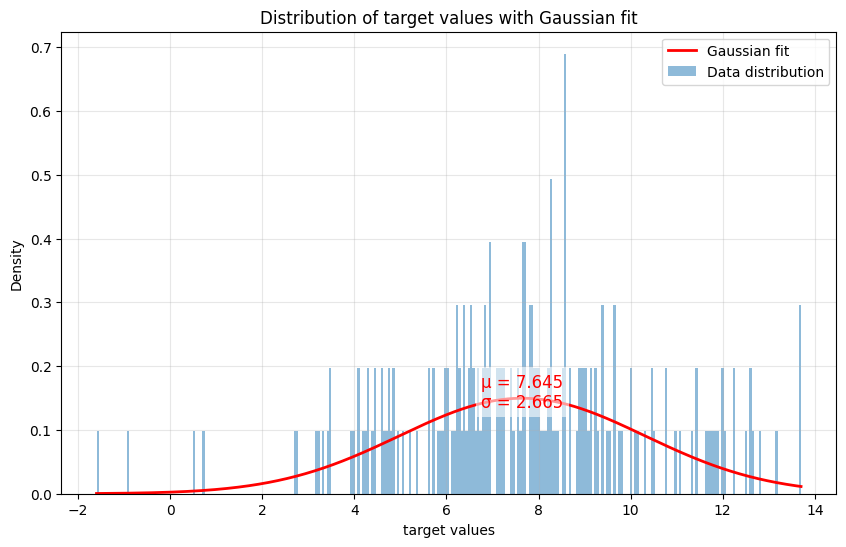

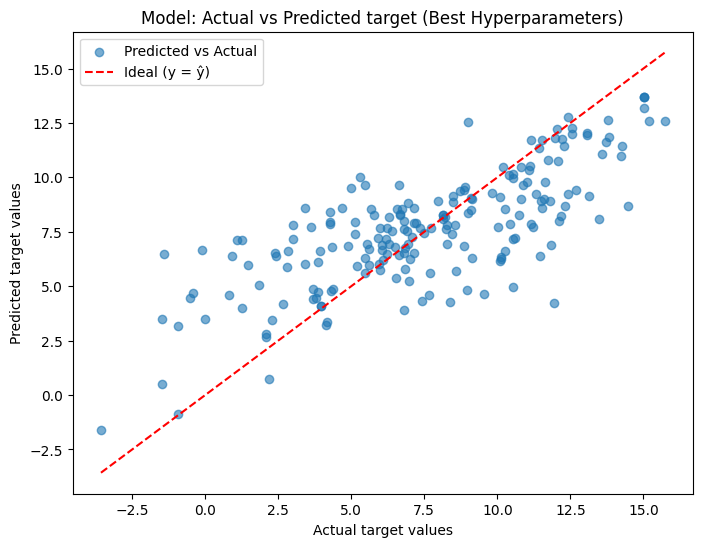

In [ ]:
r_fingerprint=2
Bits_fingerprint=2048

def protein_chain_encoder(chain):
    v = np.zeros(26)
    for i in range(len(chain)):
        aa = chain[i]
        if aa in 'ABCDEFGHIJKLMNOPQRSTUVWXYZ':
            v[ord(aa) - ord('A')] += 1
    return v

fp = np.array([smiles_to_fingerprint(s) for s in preprocessed_data['smiles']])
pc = np.array([protein_chain_encoder(c) for c in preprocessed_data['seq']])
X = np.concatenate((fp, pc), axis=1)
y = preprocessed_data['target'].values


# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Hyperparameter grid for Random Forest
param_grid = {
    'n_estimators': np.linspace(10, 100, 5).astype(int),
    'max_depth': np.linspace(10, 100, 5).astype(int),
    'min_samples_split': [2]
}

rf = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1, return_train_score=True)
grid_search.fit(X_train, y_train)

# Best model and predictions
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)

# Metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Test MSE (standardized): {mse:.2f}")
print(f"Test R2 (standardized): {r2:.2f}")

# Prepare matrix for heatmap plots
results = grid_search.cv_results_
df_results = pd.DataFrame(results)
df_results['max_depth'] = df_results['param_max_depth'].fillna(-1).astype(int)
df_results['n_estimators'] = df_results['param_n_estimators'].astype(int)

# Choose a fixed value for min_samples_split, e.g. 2
fixed_split = 2
filtered = df_results[df_results['param_min_samples_split'] == fixed_split]

# Calculate MSE and R2 for each parameter combination
mse_matrix = filtered.pivot(index='max_depth', columns='n_estimators', values='mean_test_score')
r2_matrix = filtered.pivot(index='max_depth', columns='n_estimators', values='mean_train_score')

# Plot MSE heatmap (note: mean_test_score is negative MSE, so invert sign)
plt.figure(figsize=(8,6))
plt.title('Random Forest Hyperparameter Grid - MSE (CV, standardized)')
plt.xlabel('n_estimators')
plt.ylabel('max_depth')
im = plt.imshow(-mse_matrix.values, cmap='viridis', aspect='auto', origin='lower')
plt.xticks(np.arange(len(mse_matrix.columns)), mse_matrix.columns)
plt.yticks(np.arange(len(mse_matrix.index)), mse_matrix.index)
plt.colorbar(im, label='MSE')
plt.show()

# Plot R2 heatmap (using train score for illustration, can be replaced with test R2 if calculated)
plt.figure(figsize=(8,6))
plt.title('Random Forest Hyperparameter Grid - R2 (Train, standardized)')
plt.xlabel('n_estimators')
plt.ylabel('max_depth')
im = plt.imshow(r2_matrix.values, cmap='plasma', aspect='auto', origin='lower')
plt.xticks(np.arange(len(r2_matrix.columns)), r2_matrix.columns)
plt.yticks(np.arange(len(r2_matrix.index)), r2_matrix.index)
plt.colorbar(im, label='R2')
plt.show()

#best model evaluation plots
print("Best hyperparameters:", grid_search.best_params_)
gaussian_fit(y_pred)
prediction_plot(y_test, y_pred)
